# Test Model HTR — Fixed Version
Preprocessing saat testing **identik** dengan saat training.

In [1]:
# ============================================================
# KONFIGURASI — edit bagian ini saja
# ============================================================
CHECKPOINT_PATH = "checkpoint_ocr_tuf.pt"   # path checkpoint model
GAMBAR_TES      = "dataset_asli/009.png"     # path gambar yang ingin diprediksi
# ============================================================

In [2]:
import os
import string
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ── Kamus karakter (HARUS SAMA PERSIS dengan saat training) ──
all_chars    = string.ascii_letters + string.digits + " .,()?!-"
char_map     = {"[BLANK]": 0}
for idx, char in enumerate(all_chars):
    char_map[char] = idx + 1
char_map_inv = {v: k for k, v in char_map.items()}
char_map_inv[0] = ""   # blank CTC
NUM_CLASSES  = len(char_map)
print(f'✅ Kamus karakter: {NUM_CLASSES} kelas')

✅ Kamus karakter: 71 kelas


In [3]:
# ── Definisi arsitektur model (HARUS SAMA dengan saat training) ──
class CRNNModel(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d((2,1),(2,1)),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))
        self.rnn = nn.LSTM(512, hidden_size, bidirectional=True, num_layers=2, batch_first=True)
        self.fc  = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = self.adaptive_pool(x).squeeze(2)
        x = x.permute(0, 2, 1)
        x, _ = self.rnn(x)
        x = self.fc(x)
        return x.permute(1, 0, 2)

print('✅ Arsitektur model terdefinisi')

✅ Arsitektur model terdefinisi


In [4]:
# ── Load checkpoint ───────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CRNNModel(num_classes=NUM_CLASSES).to(device)

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"❌ Checkpoint '{CHECKPOINT_PATH}' tidak ditemukan!")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Model dimuat dari Epoch {checkpoint['epoch']+1} | Device: {device}")

✅ Model dimuat dari Epoch 50 | Device: cuda


In [5]:
# ── CTC Greedy Decoder ────────────────────────────────────────
def ctc_decode(output):
    arg_maxes   = torch.argmax(output, dim=2).permute(1, 0)  # [Batch, Width]
    decoded     = ""
    last_char   = None
    for idx in arg_maxes[0]:
        char_idx = idx.item()
        if char_idx != 0 and char_idx != last_char:
            decoded += char_map_inv.get(char_idx, '')
        last_char = char_idx
    return decoded

print('✅ Decoder siap')

✅ Decoder siap


In [6]:
# ── FIX UTAMA: Preprocessing IDENTIK dengan training ────────
#
# Saat training (OnTheFlyTRDGDataset), pipeline-nya adalah:
#   1. PIL Image (RGB dari TRDG)
#   2. Grayscale
#   3. Resize((64, 256))   ← gepeng paksa
#   4. ToTensor
#   5. Normalize((0.5,),(0.5,))
#
# Maka testing harus SAMA PERSIS:

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 256)),      # ← sama persis dengan training!
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


def predict_image(image_path):
    """Prediksi teks dari satu gambar baris tulisan tangan."""
    if not os.path.exists(image_path):
        print(f'❌ File tidak ditemukan: {image_path}')
        return None

    # Baca sebagai PIL (tidak perlu Otsu — biarkan Grayscale+Normalize yang handle)
    img = Image.open(image_path).convert('RGB')

    img_tensor = transform_test(img).unsqueeze(0).to(device)  # [1,1,64,256]

    with torch.no_grad():
        output = model(img_tensor)
        probs  = output.log_softmax(2)

    return ctc_decode(probs)


print('✅ Fungsi predict_image siap')

✅ Fungsi predict_image siap


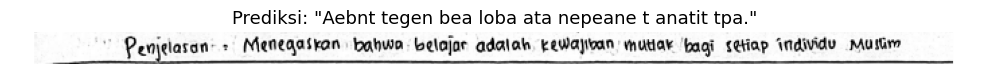

Hasil Prediksi: Aebnt tegen bea loba ata nepeane t anatit tpa.


In [7]:
# ── Prediksi satu gambar + visualisasi ───────────────────────
hasil = predict_image(GAMBAR_TES)

if hasil is not None:
    # Tampilkan gambar dan hasil
    img_show = Image.open(GAMBAR_TES).convert('L')
    plt.figure(figsize=(10, 2))
    plt.imshow(img_show, cmap='gray')
    plt.title(f'Prediksi: "{hasil}"', fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Hasil Prediksi: {hasil}')

In [8]:
# ── [OPSIONAL] Prediksi semua gambar di satu folder ──────────
FOLDER_TES = "dataset_asli"   # ← ganti sesuai folder hasil segmentasi

gambar_list = sorted([
    os.path.join(FOLDER_TES, f)
    for f in os.listdir(FOLDER_TES)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

print(f'Memproses {len(gambar_list)} gambar...\n')

for path in gambar_list:
    hasil = predict_image(path)
    nama  = os.path.basename(path)
    print(f'  {nama:15s}  →  {hasil}')

Memproses 39 gambar...

  001.png          →  A
  002.png          →  I uu
  003.png          →  A
  004.png          →  MWlau!
  005.png          →  A
  006.png          →  Neillll.
  007.png          →  Iltumuul
  008.png          →  Aa
  009.png          →  Aebnt tegen bea loba ata nepeane t anatit tpa.
  010.png          →  I
  011.png          →  Tuolalmalbanble
  012.png          →  Iboub
  013.png          →  T
  014.png          →  Mnbo
  015.png          →  T Ibt po ma lini bupi.
  016.png          →  An ul na l. u Ia l a duainid a lina lmpa.
  017.png          →  T al ii u buoal.
  018.png          →  T bui n kea Tua melinani meina iabaimea.
  019.png          →  I
  020.png          →  Ell
  021.png          →  T i d ahad aia lulepual. eue be be ma lba.
  022.png          →  A
  023.png          →  Hm ealbeneto li beneoe y ann n a a.
  024.png          →  I
  025.png          →  E
  026.png          →  F elidrulmnli lea alu earn a eana a.
  027.png          →  Eulmlulmntn
  